<a href="https://colab.research.google.com/github/CarlosPossi/Engenharia_De_Software/blob/main/Exercicios_da_Aula_5_%7C_Eng_Software.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **💻 Exercício Prático — Do Miro ao Python**
**Contexto:** Você vai modelar e implementar um Sistema de Biblioteca Digital (tipo Kindle Unlimited).
<br>
<br>

## ***Parte 1: Diagrama no Miro e Draw.io***
*Atores:* Leitor, Bibliotecário, Sistema de Pagamento
<br>
<br>

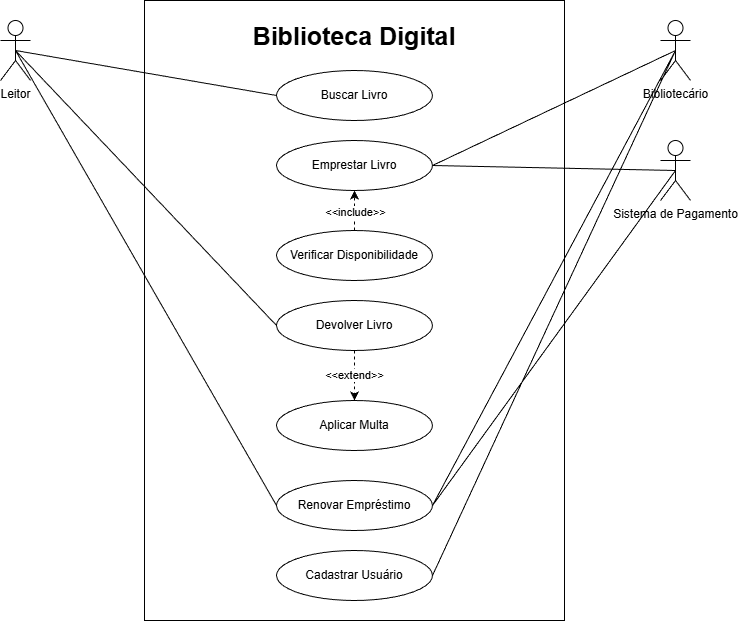

## ***Parte 2: Especificação***
*Documente o UC:* "Emprestar Livro" usando o template:
<br>
<br>

**UC-02: Emprestar Livro**
<br>
═════════════════════════════════════════════════════════════════════
<br>
**Ator Principal:** Leitor
<br>
<br>
**Pré-condições:** Leitor tem que ser cadastrado no sistema, O livro que está sendo solicitado deve está no catálogo da biblioteca.
<br>
<br>
***FLUXO PRINCIPAL:***
<br>
* 1. Leitor realiza a solicitação de empréstimo de um livro, informando o título desejado
* 2. O bibliotecário realiza a verificação da disponibilidade do livro <<_include_>>
* 3. O bibliotecário registra o empréstimo do livro, vinculando o nome do leitor ao título do livro emprestado
* 4. Bibliotecário altera o status do livro para "Emprestado"
* 5. O bibliotecário confirma a conclusão da operação para o usuário
* 6. O Leitor devolve o livro
* 7. O bibliotecário verifica a data de entrega do livro <<_include_>>
* 8. O bibliotecário registra a devolução do livro, retirando o livro do status "Emprestado".
<br>
<br>

***FLUXO ALTERNATIVO (2a, 2b):***
<br>
* **2a. Livro procurado não está disponível na biblioteca**
  
  → O Bibliotecário informa que a obra desejada não se encontra no acervo e sugere uma alternativa ao leitor.
<br>

* **2b. Livro Indisponível**

  → Caso o livro procurado esteja emprestado, o bibliotecário informa que a obra não está disponível e sugere a realização de uma reserva ou uma nova busca.
<br>
<br>

***FLUXO DE EXCEÇÃO (7a):***
<br>

* **7a. Livro excedeu a data limite de entrega do livro**  
  → O Bibliotecário informa que haverá uma multa a ser paga pelo atraso e gera a multa para esse leitor realizar o pagamento.
<br>
  
**Pós-condições:** O status do livro é atualizado para Disponível no banco de dados da biblioteca.  E uma nova entrada é gerada e armazenada na lista de empréstimos ativos.

**Comentário sobre o que o diagrama representa e as decisões de modelagem:**
<br>
O diagrama representa um caso de uso de uma Biblioteca Digital, mostrando as interações entre os atores (Leitor e Bibliotecário) e os principais fluxos do processo de empréstimo de livros.
A modelagem utiliza relações de <"include"> para comportamentos obrigatórios (como verificação de disponibilidade) e <"extend"> para situações condicionais (como aplicação de multa).
Isso permite separar o fluxo principal de variações e exceções, deixando o processo mais modular, claro e alinhado à UML.

## ***Parte 3: Implementação em Python***
No Google Colab ou VS Code — sem classes, só listas e dicionários!

In [ ]:
# ============================================================
# 🏛️ SISTEMA DE BIBLIOTECA DIGITAL — Biblioteca FIAP
# Cada seção = um Caso de Uso do diagrama que você fez no Miro
# ============================================================
# ----------------------------
# 📦 DADOS DO SISTEMA
# (imagine como o "banco de dados" por enquanto)
# ----------------------------
catalogo = [
    {"titulo": "Clean Code",            "autor": "Robert C. Martin", "disponivel": True},
    {"titulo": "The Pragmatic Programmer", "autor": "Hunt & Thomas", "disponivel": True},
    {"titulo": "Design Patterns",       "autor": "Gang of Four",     "disponivel": True},
]
emprestimos = []   # lista de {"leitor": ..., "livro": ...}

# ============================================================
# UC-01: LISTAR CATÁLOGO
# Ator: Leitor
# ============================================================
print("📚 Catálogo disponível:")
for livro in catalogo:
    status = "✅" if livro["disponivel"] else "❌"
    print(f"  {status} {livro['titulo']} — {livro['autor']}")

# ============================================================
# UC-02: BUSCAR LIVRO  ←← complete aqui!
# Ator: Leitor
# Pré-condição: catálogo não vazio
# ============================================================

print("\n🔍 Buscando livro...")
busca = input(str("Digite o nome do livro completo: ")) # o leitor digitou isso
encontrado = False

for livro in catalogo:
  if busca.lower() in livro["titulo"].lower():
    print(f"✅ Livro '{busca}' encontrado!")
    encontrado = True
    break

if not encontrado:
    print(f"❌ Livro '{busca}' não encontrado.")

# ============================================================
# UC-03: EMPRESTAR LIVRO
# Ator: Leitor
# <<include>> UC-04 Verificar Disponibilidade
# ============================================================

print("\n📌 Empréstimo:")
leitor  = input(str("Qual é o seu nome completo?: "))
titulo  = busca.lower()
# <<include>> — verificar disponibilidade (sempre acontece)
livro_encontrado = None
for livro in catalogo:
    if busca.lower() in livro["titulo"].lower():
        livro_encontrado = livro
        break
if livro_encontrado is None:
    print("❌ Livro não encontrado no catálogo.")
elif livro_encontrado["disponivel"] == False:
    # Fluxo de exceção
    print(f"⚠️  '{titulo}' já está emprestado!")
else:
    # Fluxo principal
    livro_encontrado["disponivel"] = False
    emprestimos.append({"leitor": leitor, "livro": titulo})
    print(f"\n✅ '{titulo}' emprestado para {leitor}!")

# ============================================================
# UC-04: DEVOLVER LIVRO  ←← complete aqui!
# Ator: Leitor
# <<extend>> UC-05 Aplicar Multa (só se atrasado)
# ============================================================

print("\n🔄 Devolução:")
leitor_devolvendo = leitor
titulo_devolvendo = titulo

encontrado = False

for emprestimo in emprestimos[:]:
  if emprestimo["leitor"] == leitor_devolvendo and emprestimo["livro"] == titulo_devolvendo:

    for livro in catalogo:
      if livro["titulo"].lower() == titulo_devolvendo.lower():
        livro["disponivel"] = True
        break

    emprestimos.remove(emprestimo)

    print(f"📚 Livro '{titulo_devolvendo}' devolvido por {leitor_devolvendo}!")
    encontrado = True

# Bibliotecário vendo se houve atraso na entrega  <<include>>
    atraso = input("\nHouve atraso? (s/n): ").lower()

#Bibliotecário aplicando a multa se houve atraso <<extend>>
    if atraso == "s":
      print("\n📋 Multa aplicada! Gerando o boleto para o realização do pagamento!")

    break

if not encontrado:
  print("❌ Empréstimo não encontrado.")

# ============================================================
# 🔎 ESTADO FINAL — confira o resultado
# ============================================================
print("\n📖 Catálogo após operações:")
for livro in catalogo:
    status = "✅" if livro["disponivel"] else "❌"
    print(f"  {status} {livro['titulo']}")
print(f"\n📋 Empréstimos ativos: {emprestimos}")

📚 Catálogo disponível:
  ✅ Clean Code — Robert C. Martin
  ✅ The Pragmatic Programmer — Hunt & Thomas
  ✅ Design Patterns — Gang of Four

🔍 Buscando livro...
Digite o nome do livro completo: clean code
✅ Livro 'clean code' encontrado!

📌 Empréstimo:
Qual é o seu nome completo?: carlos

✅ 'clean code' emprestado para carlos!

🔄 Devolução:
📚 Livro 'clean code' devolvido por carlos!

Houve atraso? (s/n): s

📋 Multa aplicada! Gerando o boleto para o realização do pagamento!

📖 Catálogo após operações:
  ✅ Clean Code
  ✅ The Pragmatic Programmer
  ✅ Design Patterns

📋 Empréstimos ativos: []


**Comentário sobre o que o código implementa e o que foi aprendido:**
<br>
O código implementa um sistema simples de biblioteca digital baseado em casos de uso, simulando operações como listar, buscar, emprestar e devolver livros, além de tratar disponibilidade e multa por atraso.
Ele transforma o diagrama UML em uma implementação funcional, conectando os fluxos principais, alternativos e de exceção em lógica real de programação.
O principal aprendizado é como requisitos e casos de uso podem ser traduzidos diretamente em código estruturado, reforçando a importância de modelagem antes da implementação.

**Comentário sobre o output exibido:**
<br>
O output demonstra a execução completa do fluxo de um sistema de biblioteca, incluindo listagem do catálogo, busca de livro, empréstimo, devolução e aplicação de multa em caso de atraso.
Ele evidencia o funcionamento correto dos casos de uso implementados, com atualização do estado do sistema (livros disponíveis e empréstimos ativos) após cada operação.
Isso reforça a consistência entre o fluxo modelado no diagrama e sua implementação em código.